In [13]:
import jax
import jax.numpy as jnp
from jax.experimental import sparse

# create a sparse matrix
A = jnp.array([[1, 0, 0], [0, 0, 2], [0, 3, 0]])
A = sparse.BCOO.fromdense(A)
print(A.shape)
print(A.indices.shape)

# create a random vector with shape (num_nonzero_elements, 1)
x = jnp.array([[1, 2, 3], [3,4 ,5]]).reshape(2, -1)
batch_idx = jnp.broadcast_to(A.indices, (2, ) + A.indices.shape)
print(x.shape)

B = sparse.BCOO((x, batch_idx), shape=(2,) + A.shape)

(3, 3)
(3, 2)
(2, 3)


In [11]:
# densify the sparse matrix
B = B.todense()

In [12]:
print(B[0])
print(B[1])

[[1 0 0]
 [0 0 2]
 [0 3 0]]
[[3 0 0]
 [0 0 4]
 [0 5 0]]


In [19]:
B @ B.transpose((0, 2, 1))

AttributeError: 'BCOO' object has no attribute 'conj'

In [25]:
import torch
A = torch.arange(5*5)
A = A.reshape(5, 5)
print(A)

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24]])


In [30]:
A = torch.arange(5*5)
A = A.reshape(5, 5)
print(A)
B = torch.tensor([[0,0,1,1,1],
                  [0,0,1,0,1],
                  [0,0,1,1,1],
                  [0,0,0,0,0],
                  [0,0,0,0,0]])

A = A[None,...]
B = B[None,...]
print(A.shape)
A = torch.nn.functional.pad(A, (2, 2,2,2), 'circular')
out = torch.nn.functional.conv2d(A, B[None,...], padding='valid')
print(out)

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24]])
torch.Size([1, 5, 5])
tensor([[[ 93, 101, 109, 102, 100],
         [ 83,  91,  99,  92,  90],
         [ 48,  56,  64,  57,  55],
         [ 88,  96, 104,  97,  95],
         [128, 136, 144, 137, 135]]])


tensor([[[ 93, 101, 109, 102, 100],
         [ 83,  91,  99,  92,  90],
         [ 48,  56,  64,  57,  55],
         [ 88,  96, 104,  97,  95],
         [128, 136, 144, 137, 135]]])

# Calculate Gaussian standard deviation from quantiles
Here we test the correct way to use quantiles to compute the standard deviation of a Gaussian distribution of mean $\mu$ and standard deviation $\sigma$

For a Gauassian distribution
$$ \mathcal{N}(\mu, \sigma) = \frac{1}{\sqrt{2\pi \sigma^2}}\exp(-\frac{(x - \mu)^2}{2\sigma^2})$$
what would be the quantile at $x = \mu + \sigma$?

The CDF of the distribution is
$$
\Phi(\frac{x - \mu}{\sigma}) = \frac{1}{2}[1 + \text{erf}(\frac{x - \mu}{\sqrt{2}\sigma})]
$$

So the value of CDF at $x = \mu + \sigma$ is $\Phi(1) \approx 0.8413$. Similarly, the CDF of $x = \mu - \sigma$ is $\Phi(-1) \approx 0.1587$. Therefore, the corresponding quantiles should be $q_{0.1587}$ and $q_{0.8413}$ and the approximated standard deviation would be 
$$
\sigma = \frac{q_{0.8413} - q_{0.1587}}{2}
$$
So in training the deep ensemble to quantify the aleatoric uncertainty, the estimation is
$$
\hat{\sigma^2} = \frac{1}{M}\sum(\frac{q_{0.8413} - q_{0.1587}}{2})^2
$$

In [14]:
# some experiment to show this reuslt is correct using size 10 vectors

# for standard normal distribution
import numpy as np
from scipy.stats import norm

mu = np.zeros(10)
std = np.ones(10)
samples = norm.rvs(loc=mu, scale=std, size=(1000, 10))

q_84 = np.percentile(samples, 84.13, axis=0)
q_16 = np.percentile(samples, 15.87, axis=0)

sig_approx = (q_84 - q_16) / 2
print(sig_approx)
# out 
#[1.04020425 1.04487885 1.03526406 0.99726287 1.02803725 1.0488846
# 1.02138444 0.96254643 0.96950713 0.96601417]


# # for a non-standard normal distribution
mu = np.arange(10)
std = np.arange(10)
samples = norm.rvs(loc=mu, scale=std, size=(1000, 10))

q_84 = np.percentile(samples, 84.13, axis=0)
q_16 = np.percentile(samples, 15.87, axis=0)

sig_approx = (q_84 - q_16) / 2
print(sig_approx)
# [0.         0.98812219 2.02960867 2.873855   4.11843324 5.10801884
# 5.76956213 7.04452462 7.57206025 8.89273772]

[1.04020425 1.04487885 1.03526406 0.99726287 1.02803725 1.0488846
 1.02138444 0.96254643 0.96950713 0.96601417]
[0.         0.98812219 2.02960867 2.873855   4.11843324 5.10801884
 5.76956213 7.04452462 7.57206025 8.89273772]


# HPO results

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./hpo_results/hpo_FNO_L32/results.csv')
df = df[df['objective']!='F']

# cast the objective to float
df['objective'] = df['objective'].astype(float)



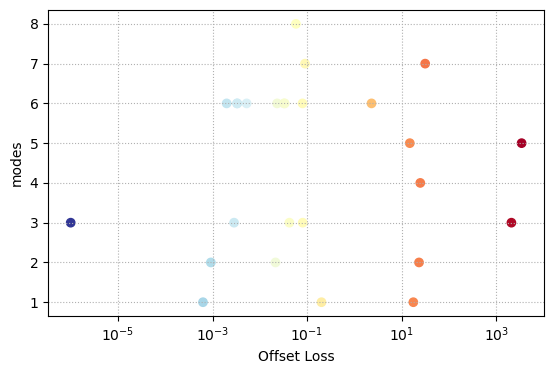

In [27]:
fig, ax = plt.subplots()
offset_loss = -df['objective'] - np.min(-df['objective'].values) + 1e-6 
ax.set_box_aspect(1/1.62)
param = "modes"
ax.scatter(offset_loss, df[f'p:{param}'], c=np.log(offset_loss), cmap='RdYlBu_r')
ax.grid(linestyle='dotted')
ax.set_xlabel('Offset Loss')
ax.set_ylabel(f'{param}')
if param == 'lr':
    ax.set_yscale('log')
ax.set_xscale('log')

fig.savefig(f'../../MatrixPreNet/figures/hpo_fno_l32_{param}_vs_offset_loss.pdf', bbox_inches='tight')

# Make CG plots


In [1]:
import numpy as np
import matplotlib.pyplot as plt

L = 8

no_pc_hist = np.load(f"./plot_data/M8_D{L}_no_pc_hist.npz")
nn_pc_hist = np.load(f"./plot_data/M8_D{L}_nn_pc_hist.npz")
ic_pc_hist = np.load(f"./plot_data/M8_D{L}_ic_pc_hist.npz")


no_pc = np.asarray(no_pc_hist["hist"])
no_pc_time = no_pc_hist["time"]

nn_pc = np.asarray(nn_pc_hist["hist"])
nn_pc_time = nn_pc_hist["time"]

ic_pc = np.asarray(ic_pc_hist["hist"])
ic_pc_time = ic_pc_hist["time"]

print(no_pc.shape)
print(nn_pc.shape)

print(no_pc_time, nn_pc_time, ic_pc_time)


(105, 200)
(52, 200)
4.530500888824463 4.221396207809448 116.3903911113739


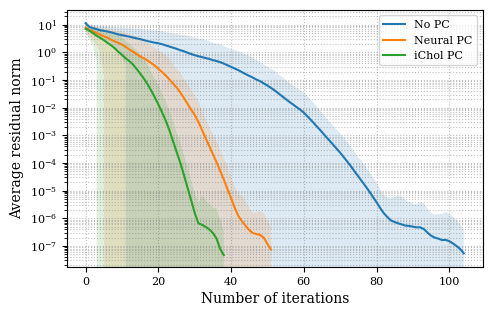

In [2]:
from plot import set_size

fig, ax = plt.subplots(figsize=set_size(390))
ax.set_box_aspect(1 / 1.62)

ax.plot(np.mean(no_pc, axis=1), label="No PC")
ax.plot(np.mean(nn_pc, axis=1), label="Neural PC")
ax.plot(np.mean(ic_pc, axis=1), label="iChol PC")
# plot 1.96 * std
ax.fill_between(
    np.arange(no_pc.shape[0]),
    np.mean(no_pc, axis=1) - 1.96 * np.std(no_pc, axis=1),
    np.mean(no_pc, axis=1) + 1.96 * np.std(no_pc, axis=1),
    alpha=0.15,
)
ax.fill_between(
    np.arange(nn_pc.shape[0]),
    np.mean(nn_pc, axis=1) - 1.96 * np.std(nn_pc, axis=1),
    np.mean(nn_pc, axis=1) + 1.96 * np.std(nn_pc, axis=1),
    alpha=0.15,
)
ax.fill_between(
    np.arange(ic_pc.shape[0]),
    np.mean(ic_pc, axis=1) - 1.96 * np.std(ic_pc, axis=1),
    np.mean(ic_pc, axis=1) + 1.96 * np.std(ic_pc, axis=1),
    alpha=0.15,
)
ax.set_yscale("log")
ax.grid(which="both", color="gray", linestyle="dotted", alpha=0.5)
ax.set_xlabel("Number of iterations")
ax.set_ylabel("Average residual norm")
ax.legend()
fig.savefig(f"../../MatrixPreNet/figures/M8_L{L}_residual_hist-newtest.pdf", bbox_inches='tight')

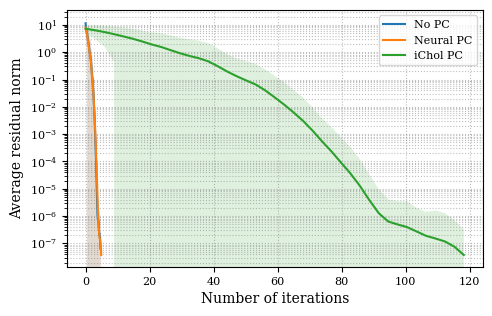

In [19]:
# plot the time vs residual

fig, ax = plt.subplots(figsize=set_size(390))
ax.set_box_aspect(1 / 1.62)

no_pc_time_steps = np.linspace(0, no_pc_time, no_pc.shape[0])
nn_pc_time_steps = np.linspace(0, nn_pc_time, nn_pc.shape[0])
ic_pc_time_steps = np.linspace(0, ic_pc_time, ic_pc.shape[0])

ax.plot(no_pc_time_steps, np.mean(no_pc, axis=1), label="No PC")
ax.plot(nn_pc_time_steps, np.mean(nn_pc, axis=1), label="Neural PC")
ax.plot(ic_pc_time_steps, np.mean(ic_pc, axis=1), label="iChol PC")
# plot 1.96 * std
ax.fill_between(
    no_pc_time_steps,
    np.mean(no_pc, axis=1) - 1.96 * np.std(no_pc, axis=1),
    np.mean(no_pc, axis=1) + 1.96 * np.std(no_pc, axis=1),
    alpha=0.15,
)
ax.fill_between(
    nn_pc_time_steps,
    np.mean(nn_pc, axis=1) - 1.96 * np.std(nn_pc, axis=1),
    np.mean(nn_pc, axis=1) + 1.96 * np.std(nn_pc, axis=1),
    alpha=0.15,
)
ax.fill_between(
    ic_pc_time_steps,
    np.mean(ic_pc, axis=1) - 1.96 * np.std(ic_pc, axis=1),
    np.mean(ic_pc, axis=1) + 1.96 * np.std(ic_pc, axis=1),
    alpha=0.15,
)
ax.set_yscale("log")
ax.grid(which="both", color="gray", linestyle="dotted", alpha=0.5)
ax.set_xlabel("Number of iterations")
ax.set_ylabel("Average residual norm")
ax.legend()
fig.savefig("../../MatrixPreNet/figures/M8_L8_residual_time.pdf", bbox_inches='tight')

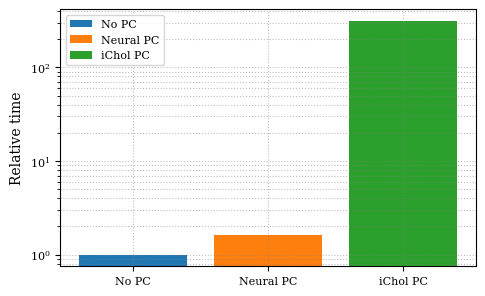

In [26]:
fig, ax = plt.subplots(figsize=set_size(390))
ax.set_box_aspect(1 / 1.62)

no_pc_ratio = no_pc_time / no_pc_time
nn_pc_ratio = nn_pc_time / no_pc_time
ic_pc_ratio = ic_pc_time / no_pc_time

# bar plot
ax.bar(0, no_pc_ratio, label="No PC")
ax.bar(1, nn_pc_ratio, label="Neural PC")
ax.bar(2, ic_pc_ratio, label="iChol PC")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["No PC", "Neural PC", "iChol PC"])
ax.set_ylabel("Relative time")
ax.set_yscale("log")
ax.grid(which="both", color="gray", linestyle="dotted", alpha=0.5)
ax.legend()
fig.savefig(f"../../MatrixPreNet/figures/M8_L{L}_time_ratio.pdf", bbox_inches='tight')